<a href="https://colab.research.google.com/github/lithikaneelakandan56-ctrl/ml_practice/blob/main/ML/day8_xgboost_wine_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

In [3]:
data = load_wine()
X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)
y = pd.Series(data.target)
print("Dataset loaded successfully!")
print("Shape:", X.shape)

Dataset loaded successfully!
Shape: (178, 13)


In [4]:
print(X.head())
print(y.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [6]:
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])
print("\nFeature names:")
print(X.columns.tolist())
print("\nTarget classes:")
print(data.target_names)
print("Missing values:")
print(X.isnull().sum())
print("\nTotal missing values:",X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())
print(y.value_counts())
print(data.target_names)

Number of rows: 178
Number of features: 13

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target classes:
['class_0' 'class_1' 'class_2']
Missing values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Total missing values: 0
Duplicate rows: 0
1    71
0    59
2    48
Name: count, dtype: int64
['class_0' 'class_1' 'class_2']


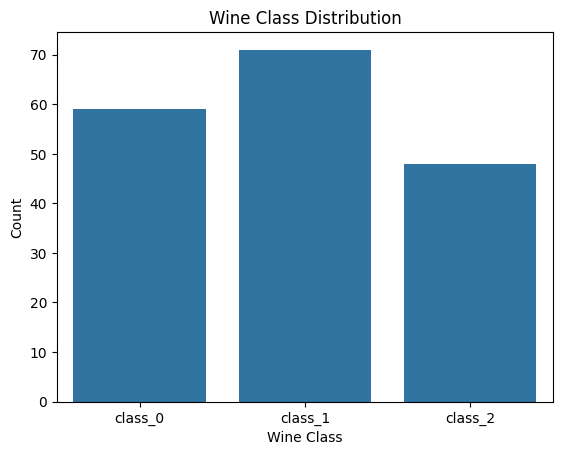

In [7]:
class_names = [data.target_names[i] for i in y]
sns.countplot(x=class_names)
plt.title("Wine Class Distribution")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()

In [8]:
X.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


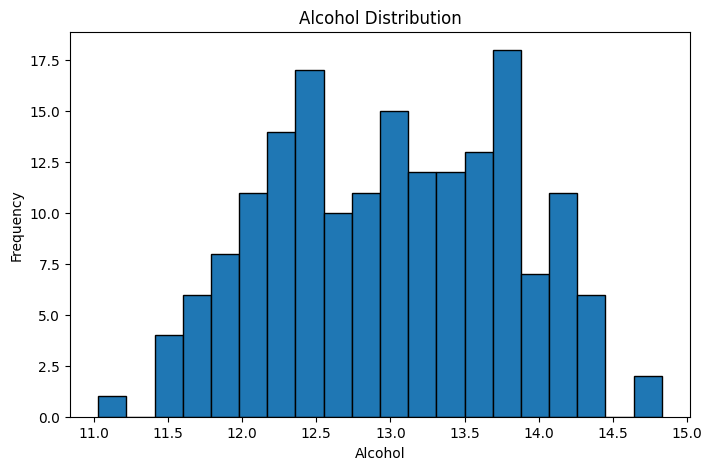

In [9]:
# histogram
plt.figure(figsize=(8,5))
plt.hist(X["alcohol"], bins=20, edgecolor="black")
plt.title("Alcohol Distribution")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()

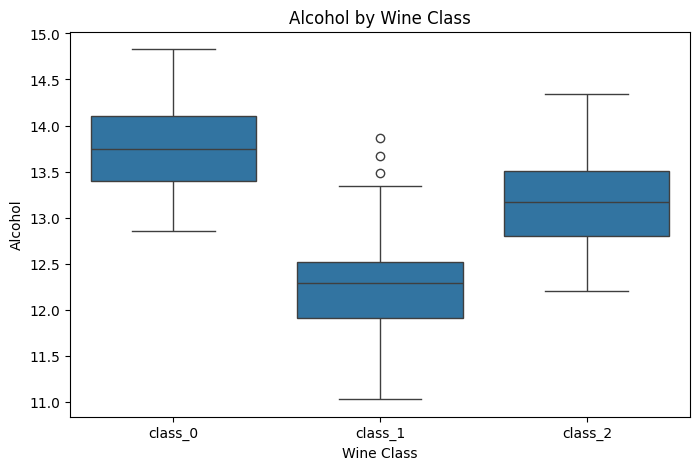

In [10]:
# boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=class_names, y=X["alcohol"])
plt.title("Alcohol by Wine Class")
plt.xlabel("Wine Class")
plt.ylabel("Alcohol")
plt.show()

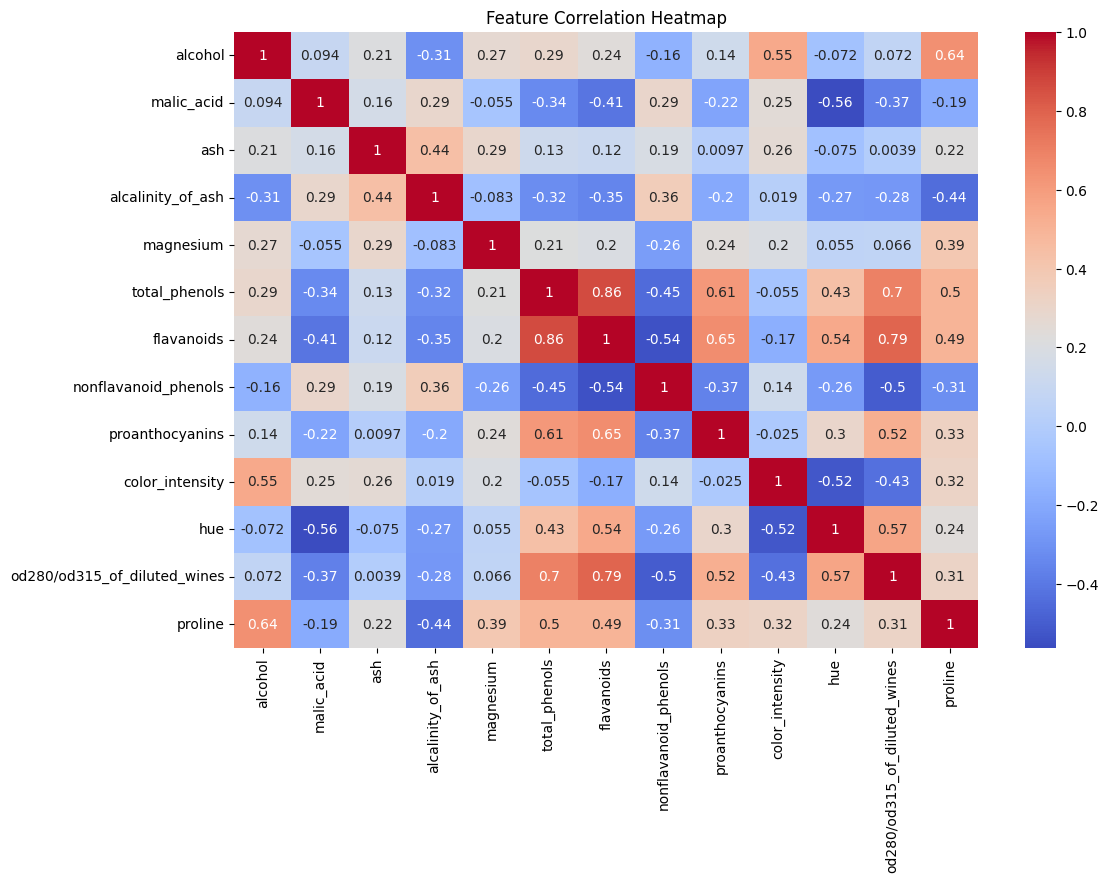

In [11]:
# correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (142, 13)
Testing data: (36, 13)


In [13]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss"
)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [14]:
y_pred = model.predict(X_test)
print(y_pred)

[0 2 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]


In [15]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")
# precision and recall
from sklearn.metrics import (precision_score,recall_score,f1_score)
precision = precision_score(y_test,y_pred,average="weighted")
recall = recall_score(y_test,y_pred,average="weighted")
f1 = f1_score(y_test,y_pred,average="weighted")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 1.0
Accuracy percentage: 100.0 %
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [16]:
# classification report
from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



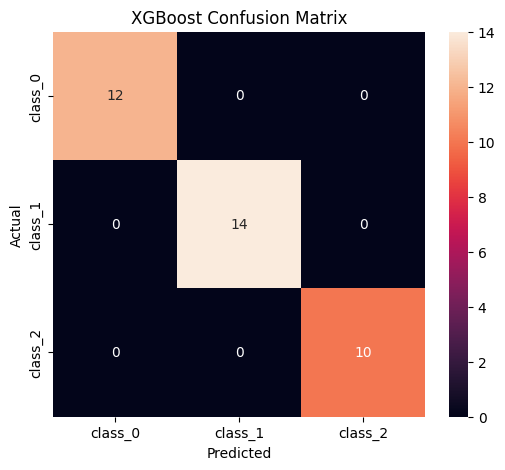

In [17]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [18]:
# feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
print(importance)

flavanoids                      0.256339
color_intensity                 0.220617
proline                         0.202031
magnesium                       0.091257
hue                             0.049014
malic_acid                      0.046193
od280/od315_of_diluted_wines    0.033515
ash                             0.029721
proanthocyanins                 0.022085
total_phenols                   0.021198
alcohol                         0.014740
nonflavanoid_phenols            0.006983
alcalinity_of_ash               0.006308
dtype: float32


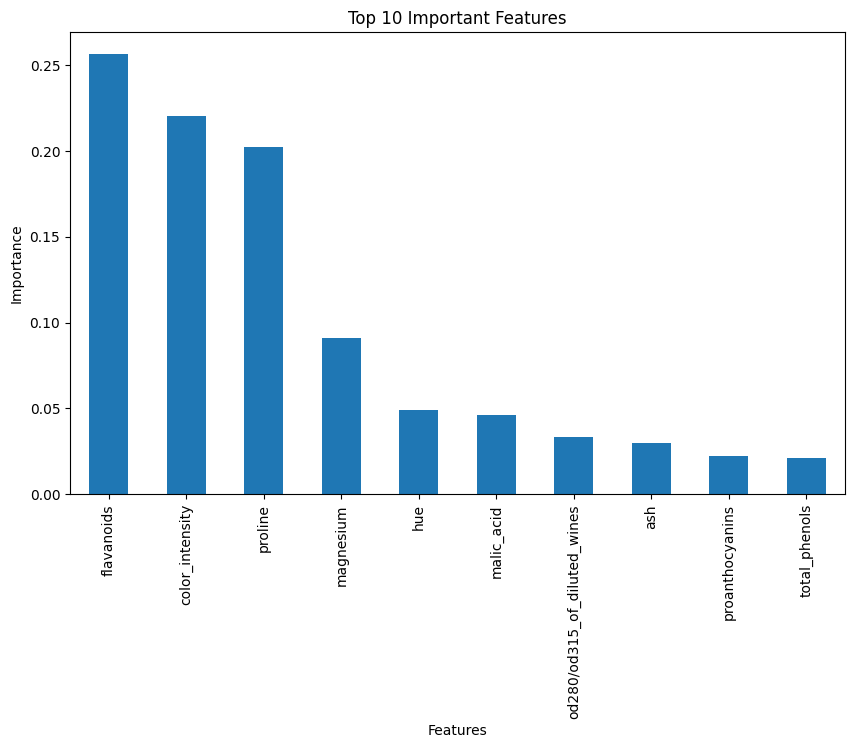

In [19]:
# plot feature importance
plt.figure(figsize=(10,6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [22]:
# comparing different number of trees
trees = [50, 100, 200]
for n in trees:
  xgb_model = XGBClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="mlogloss"
    )
  xgb_model.fit(X_train, y_train)
  predictions = xgb_model.predict(X_test)
  accuracy = accuracy_score(
        y_test,
        predictions
    )
  print(
        "Number of Trees:",
        n,
        "Accuracy:",
        accuracy
    )

Number of Trees: 50 Accuracy: 0.9722222222222222
Number of Trees: 100 Accuracy: 1.0
Number of Trees: 200 Accuracy: 0.9722222222222222


In [27]:
user_values = []
print("Enter the following wine details:\n")
for feature in X.columns:
  value = float(
        input(f"Enter {feature}: ")
    )
  user_values.append(value)

Enter the following wine details:

Enter alcohol: 33
Enter malic_acid: 55
Enter ash: 45
Enter alcalinity_of_ash: 34
Enter magnesium: 23
Enter total_phenols: 56
Enter flavanoids: 78
Enter nonflavanoid_phenols: 67
Enter proanthocyanins: 89
Enter color_intensity: 5
Enter hue: 6
Enter od280/od315_of_diluted_wines: 8
Enter proline: 9


In [28]:
user_input = pd.DataFrame(
    [user_values],
    columns=X.columns
)
print(user_input)
prediction = model.predict(user_input)
print(
    "\nPredicted Wine Class:",
    data.target_names[prediction[0]]
)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0     33.0        55.0  45.0               34.0       23.0           56.0   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity  hue  \
0        78.0                  67.0             89.0              5.0  6.0   

   od280/od315_of_diluted_wines  proline  
0                           8.0      9.0  

Predicted Wine Class: class_1


In [29]:
# prediction probability
probability = model.predict_proba(user_input)
print("\nPrediction probabilities:")
for i, class_name in enumerate(data.target_names):
  print(
        class_name,
        ":",
        round(probability[0][i] * 100, 2),
        "%"
    )


Prediction probabilities:
class_0 : 24.1 %
class_1 : 71.88 %
class_2 : 4.01 %


In [31]:
print(" XGBoost Model Performance")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

 XGBoost Model Performance
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
